# Capstone Project: Late Delivery Risk Scoring in Global Supply Chains
**Author/Team:** Aman Abuelayyan, Ameed Aburub, Dalah Hashlamoon, Ruaa Luay, and Sura Sammour.

**Date:** March, 11th 2026.

**Track:** Supervised Learning (Classification + Regression)

### **Project Objective**
To predict how late an order will be and combine that with its financial impact to produce a single, actionable continuous "Risk Score" for supply chain managers.

### **Table of Contents**
1. [Setup and Imports](#setup)
2. [Data Loading & Merging](#loading)
3. [Data Cleaning & Formatting](#cleaning)
4. [Exploratory Data Analysis (EDA)](#eda)
5. [Summary & Next Steps](#summary)

## 1. Setup and Imports <a id="setup"></a>
The necessary libraries and steps for the notbook are made first.

In [1]:
# 1. Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Allow the DataFrames to show all colmuns
pd.set_option('display.max_columns', None)

**Library Imports:** It imports core data science libraries including pandas and numpy for data manipulation, and matplotlib and seaborn for data visualization.

**Configuration:** It sets a default visualization style (whitegrid), defines a standard figure size for plots, and suppresses warnings to ensure a clean output in the notebook.

## 2. Data Loading <a id="loading"></a>
The dataset is transformed into a single DataFrame.

In [2]:
df = pd.read_csv("/content/data.csv", encoding='latin1')

df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,02-03-18 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


**Data Loading:** It reads a CSV file named data.csv from the /content/ directory into a pandas DataFrame using latin1 encoding.

**Data Inspection:** It calls df.head(5) to display the first five rows of the dataset, allowing for a quick check of the column names and initial values.

In [3]:
df.shape

(180519, 53)

**Shape Inspection:** It uses df.shape to return a tuple representing the dimensionality of the DataFrame. Based on the output, the dataset contains 180,519 rows and 53 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

**Metadata Inspection:** The `df.info()` method provides a concise summary of the DataFrame, including the number of entries, column names, non-null counts, and data types (e.g., float64, int64, object). This is essential for identifying missing values and understanding the data structure.

In [5]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,Order Customer Id,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,-84.915675,6691.379495,36221.894903,692.509764,20.664741,0.101668,90260.000000,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,21.433241,4162.918106,21045.379569,336.446807,21.800901,0.070415,52111.490959,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025986,1.000000,1.000000,19.000000,0.000000,0.000000,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,-98.446312,3258.500000,18057.000000,403.000000,5.400000,0.040000,45130.500000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,-76.847908,6457.000000,36140.000000,627.000000,14.000000,0.100000,90260.000000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,-66.370583,9779.000000,54144.000000,1004.000000,29.990000,0.160000,135389.500000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263077,20757.000000,77204.000000,1363.000000,500.000000,0.250000,180519.000000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


**Statistical Summary:** The `df.describe()` method generates descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset’s distribution, excluding NaN values. It provides metrics such as mean, standard deviation, minimum, maximum, and percentiles for numerical columns.

## 3. Data Cleaning & Formatting <a id="cleaning"></a>
**Goals for this section:**
1. Drop columns that provide no predictive value (e.g., masked passwords, empty descriptions).
2. Convert datetime strings into proper pandas `datetime` objects.
3. Create our baseline target feature: `Delay_Gap`.

In [6]:
# Step 1: Drop useless or masked columns
columns_to_drop = ['Customer Password', 'Customer Email', 'Product Description', 'Customer Fname', 'Customer Lname']
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Step 2: Convert date columns to datetime objects
# Note: The original dates have mixed formats, so we use mixed format parsing.
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], infer_datetime_format=True, errors='coerce')

# Step 3: Create 'Delay_Gap' (Target Variable for Regression)
# Formula: Real shipping days - Scheduled shipping days
df_clean['Delay_Gap'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

# Validate that real shipping days are not negative
assert df_clean['Days for shipping (real)'].min() >= 0, "Error: Negative real shipping days found!"

print("Data cleaning complete. Current shape:", df_clean.shape)
df_clean.info()

Data cleaning complete. Current shape: (180519, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country

In [8]:
df_clean.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delay_Gap
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,-2


**Data Cleaning:** It removes columns that are either empty (like 'Product Description') or contain sensitive/irrelevant information (like 'Customer Password' and 'Customer Email') to streamline the dataset.

**Date Formatting:** It converts the order and shipping date strings into proper pandas datetime objects. This is crucial for any time-based analysis or feature engineering.

**Feature Engineering:** It creates a new column, Delay_Gap, by subtracting the scheduled shipping days from the actual shipping days. This serves as your target variable to measure how late (or early) an order was.

**Validation:** It includes an assert statement to ensure there are no negative values in the 'real shipping days' column, acting as a quick quality check.

## 4. Exploratory Data Analysis (EDA) <a id="eda"></a>
EDA helps us discover the story hidden in the supply chain data. We will investigate:
* The distribution of our target variables (`Late_delivery_risk` and `Delay_Gap`).
* The relationship between shipping modes and delays.
* The financial impact of delayed orders.

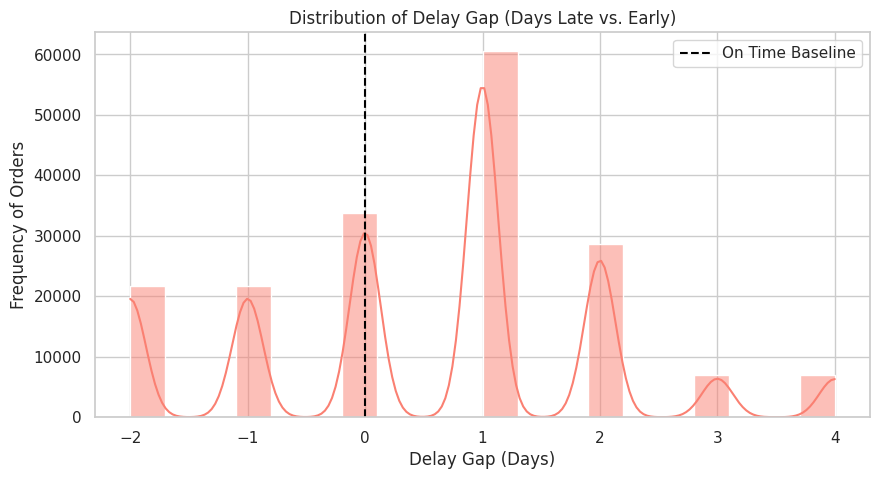

In [9]:
# EDA 1: Target Variable Distribution (Delay Gap)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Delay_Gap'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Delay Gap (Days Late vs. Early)')
plt.xlabel('Delay Gap (Days)')
plt.ylabel('Frequency of Orders')
plt.axvline(x=0, color='black', linestyle='--', label='On Time Baseline')
plt.legend()
plt.show()

**Insight:** The delay gap is slightly right-skewed. While most orders arrive around their scheduled time, there is a long tail of severe delays extending past 3 days, which represents our primary operational risk.

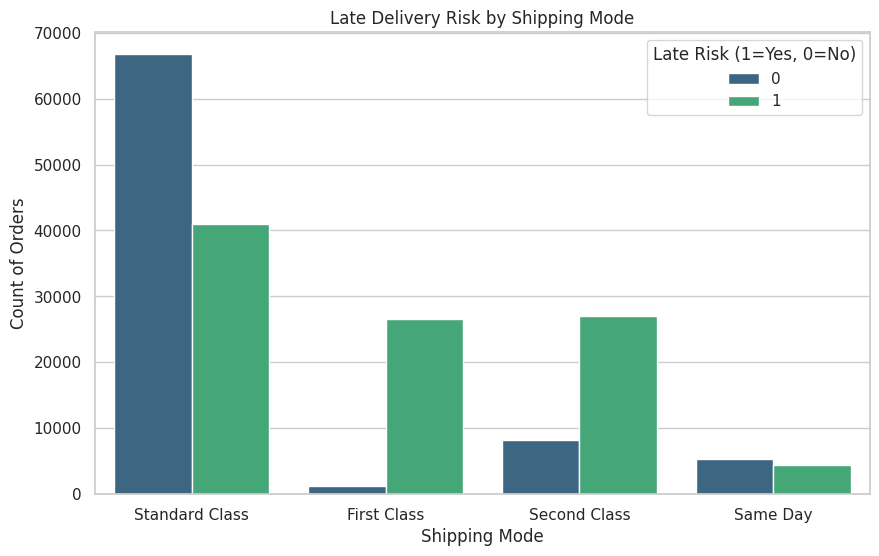

In [10]:
# EDA 2: Shipping Mode vs. Late Delivery Risk
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Shipping Mode', hue='Late_delivery_risk', palette='viridis')
plt.title('Late Delivery Risk by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Count of Orders')
plt.legend(title='Late Risk (1=Yes, 0=No)')
plt.show()

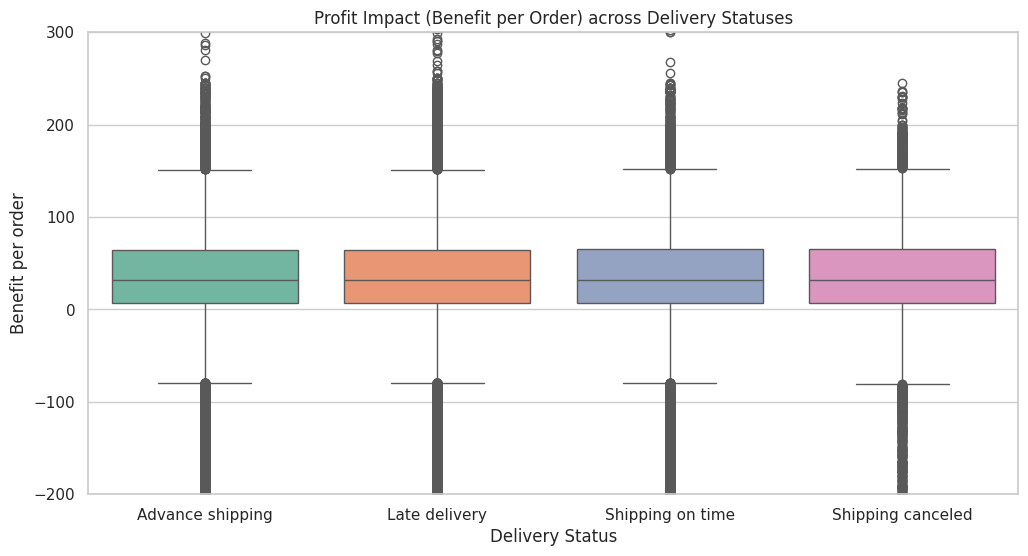

In [11]:
# EDA 3: Profit Impact by Delivery Status
plt.figure(figsize=(12, 6))
# We limit the y-axis to focus on the bulk of the data and ignore extreme outliers for the plot
sns.boxplot(data=df_clean, x='Delivery Status', y='Benefit per order', palette='Set2')
plt.title('Profit Impact (Benefit per Order) across Delivery Statuses')
plt.ylim(-200, 300) # Adjust based on your data distribution
plt.show()

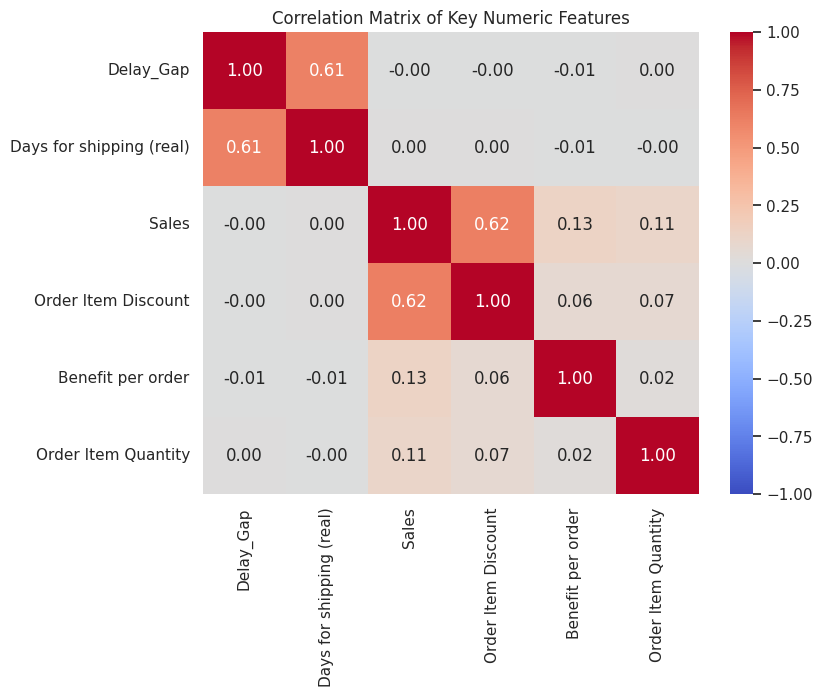

In [12]:
# EDA 4: Numeric Feature Correlation
numeric_cols = ['Delay_Gap', 'Days for shipping (real)', 'Sales', 'Order Item Discount', 'Benefit per order', 'Order Item Quantity']
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Key Numeric Features')
plt.show()